In [1]:
import torch
from evaluation_metrics import curve_posterior_slerp_deviation, curve_false_pos, curve_true_pos
from utils import NestedDiagonalGMM
from geometry_tools import lerp
from pretrained_models import NestedVAE
from torch.nn.functional import cross_entropy, mse_loss
from typing import NamedTuple
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from tqdm import tqdm
from torchmetrics.image import LearnedPerceptualImagePatchSimilarity as LPIPS, StructuralSimilarityIndexMeasure as SSIM, DeepImageStructureAndTextureSimilarity as DISTS

def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
vae = NestedVAE()

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


/net/st1/export/clusterhome/robertwiebe/ml_geometry_project/pretrained_models.py:280: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load('mo

In [14]:
nested_gmm_params = torch.load('trained_checkpoints/celeba_nested_nested_gmm_4.pt')
nested_gmm = NestedDiagonalGMM(
    means=nested_gmm_params['means'],
    variances=nested_gmm_params['variances'],
    subweights=nested_gmm_params['subweights'],
    supweights=nested_gmm_params['supweights'],
)

/tmp/user/5678/ipykernel_3219548/2406645237.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nested_gmm_params = torch.load('trained_checkpoints/celeba_nested_nested_gmm_

In [21]:
nested_gmm_params2 = torch.load('trained_checkpoints/celeba_nested_nested_gmm_4_independent.pt')
nested_gmm2 = NestedDiagonalGMM(
    means=nested_gmm_params2['means'],
    variances=nested_gmm_params2['variances'],
    subweights=nested_gmm_params2['subweights'],
    supweights=nested_gmm_params2['supweights'],
)

/tmp/user/5678/ipykernel_3219548/1888105894.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nested_gmm_params2 = torch.load('trained_checkpoints/celeba_nested_nested_gmm

In [24]:
from attribute_prediction_model_new.model import model as attribute_model_new
attribute_model_new.load_state_dict(torch.load('attribute_prediction_model_new/checkpoints/best_checkpoint.pt')['model_state_dict'])
attribute_model_new = attribute_model_new.cuda()

/tmp/user/5678/ipykernel_3219548/1447311468.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  attribute_model_new.load_state_dict(torch.load('attribute_prediction_model_ne

In [11]:
class MeanGroup(NamedTuple):
    embeds: torch.Tensor
    eucl_mean: torch.Tensor
    karcher_mean: torch.Tensor
    labels: torch.Tensor

In [12]:
means = torch.load('pickled_objects/means.pt')

/tmp/user/5678/ipykernel_3219548/3184722560.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  means = torch.load('pickled_objects/means.pt')


In [3]:
class MeansGroup2(NamedTuple):
    dec_mean: torch.Tensor
    ebm_mean1: torch.Tensor
    ebm_mean2: torch.Tensor
    mean_latent: torch.Tensor
    mean_outer: torch.Tensor

In [4]:
more_means = torch.load('pickled_objects/more_means.pt')

/tmp/user/5678/ipykernel_3219548/3836023946.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  more_means = torch.load('pickled_objects/more_means.pt')


In [8]:
embeds, eucl_mean, karcher_mean, labels = means[0]

In [5]:
def compare_means():
    fig = plt.figure()
    gs0 = fig.add_gridspec(2, 1)
    gsb = gs0[1].subgridspec(1, 2)
    axt = fig.add_subplot(gs0[0])
    axbl = fig.add_subplot(gsb[0])
    axbr = fig.add_subplot(gsb[1])

    show_img(make_grid(vae.decode(embeds)), ax=axt)
    axt.set_title('Reconstructed images')
    show_img(vae.decode(eucl_mean).detach(), ax=axbl)
    axbl.set_title('Euclidian mean')
    show_img(vae.decode(karcher_mean).detach(), ax=axbr)
    axbr.set_title('Posterior mean')

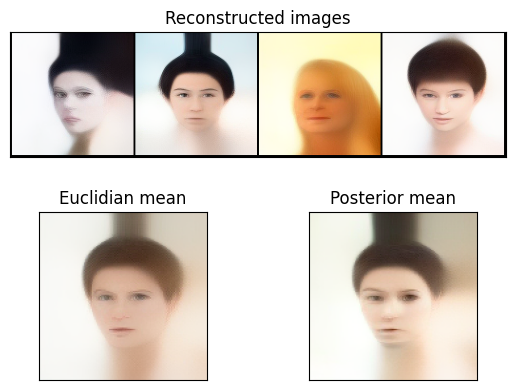

In [10]:
compare_means()

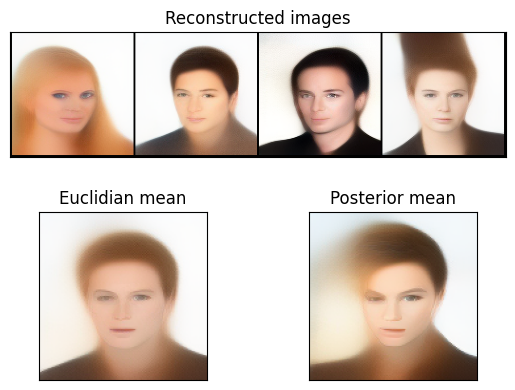

In [64]:
idx = 49
embeds, eucl_mean, karcher_mean, labels = means[idx]
compare_means()

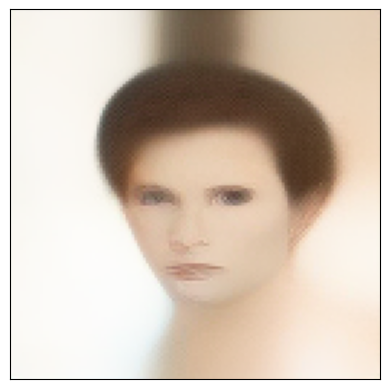

In [10]:
show_img(vae.decode(more_means[0].mean_outer))

In [55]:
compare_means()
plt.savefig(f'results/karcher_mean/mean_{idx}.png', bbox_inches='tight')
plt.close()

## Running the evaluation

In [11]:
lin_vals_list, karcher_vals_list = [], []

with torch.inference_mode():
    for embeds, eucl_mean, karcher_mean, labels in tqdm(means, 'Running evaluation'):
        avg_post = nested_gmm.posterior(embeds.cuda()).mean(0).cpu()
        eucl_post = nested_gmm.log_posterior(eucl_mean.cuda()).cpu()
        karcher_post = nested_gmm.log_posterior(karcher_mean.cuda()).cpu()
        lin_vals_list.append(cross_entropy(eucl_post, avg_post).item())
        karcher_vals_list.append(cross_entropy(karcher_post, avg_post).item())

lin_vals = np.array(lin_vals_list)
karcher_vals = np.array(karcher_vals_list)

print("--- Final results for mean posterior alignment---", end="\n\n")
print(f"Euclidian mean: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Karcher mean:   {karcher_vals.mean():.4f} ± {karcher_vals.std():.4f}")

Running evaluation: 100%|██████████| 50/50 [00:00<00:00, 330.18it/s]

--- Final results for mean posterior alignment---

Euclidian mean: 6.2663 ± 1.7459
Karcher mean:   2.3288 ± 0.4481


In [16]:
torch.mean(labels / labels.sum(-1, keepdim=True), 0)

tensor([0.0000, 0.0000, 0.1274, 0.0000, 0.0000, 0.0000, 0.0357, 0.0000, 0.0500,
        0.0357, 0.0357, 0.0417, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.1417, 0.0000, 0.0000, 0.0000, 0.1774, 0.0000, 0.0917,
        0.0500, 0.0000, 0.0000, 0.0000, 0.0000, 0.0500, 0.0000, 0.0000, 0.0000,
        0.0357, 0.0000, 0.0000, 0.1274])

In [17]:
lin_vals_list, karcher_vals_list = [], []

with torch.inference_mode():
    for embeds, eucl_mean, karcher_mean, labels in tqdm(means, 'Running evaluation'):
        # avg_post = nested_gmm.posterior(embeds.cuda()).mean(0).cpu()
        avg_post = torch.mean(labels / labels.sum(-1, keepdim=True), 0)
        eucl_post = nested_gmm.log_posterior(eucl_mean.cuda()).cpu()
        karcher_post = nested_gmm.log_posterior(karcher_mean.cuda()).cpu()
        lin_vals_list.append(cross_entropy(eucl_post, avg_post).item())
        karcher_vals_list.append(cross_entropy(karcher_post, avg_post).item())

lin_vals = np.array(lin_vals_list)
karcher_vals = np.array(karcher_vals_list)

print("--- Final results for mean posterior alignment---", end="\n\n")
print(f"Euclidian mean: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Karcher mean:   {karcher_vals.mean():.4f} ± {karcher_vals.std():.4f}")

Running evaluation: 100%|██████████| 50/50 [00:00<00:00, 1049.28it/s]

--- Final results for mean posterior alignment---

Euclidian mean: 6.1966 ± 1.6956
Karcher mean:   3.9800 ± 0.5394


In [15]:
lin_vals_list, karcher_vals_list = [], []

with torch.inference_mode():
    for embeds, eucl_mean, karcher_mean, labels in tqdm(means, 'Running evaluation'):
        # avg_post = nested_gmm.posterior(embeds.cuda()).mean(0).cpu()
        avg_post = torch.mean(labels / labels.sum(-1, keepdim=True), 0)
        eucl_post = nested_gmm.log_posterior(eucl_mean.cuda()).cpu()
        karcher_post = nested_gmm.log_posterior(karcher_mean.cuda()).cpu()
        lin_vals_list.append(cross_entropy(eucl_post, avg_post).item())
        karcher_vals_list.append(cross_entropy(karcher_post, avg_post).item())

lin_vals = np.array(lin_vals_list)
karcher_vals = np.array(karcher_vals_list)

print("--- Final results for mean posterior alignment---", end="\n\n")
print(f"Euclidian mean: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Karcher mean:   {karcher_vals.mean():.4f} ± {karcher_vals.std():.4f}")

Running evaluation: 100%|██████████| 50/50 [00:00<00:00, 269.46it/s]

--- Final results for mean posterior alignment---

Euclidian mean: 6.1966 ± 1.6956
Karcher mean:   3.9800 ± 0.5394


In [18]:
lin_vals_list, karcher_vals_list = [], []

with torch.inference_mode():
    for embeds, eucl_mean, karcher_mean, labels in tqdm(means, 'Running evaluation'):
        # avg_post = nested_gmm.posterior(embeds.cuda()).mean(0).cpu()
        avg_post = torch.mean(labels / labels.sum(-1, keepdim=True), 0)
        eucl_post = nested_gmm.posterior(eucl_mean.cuda()).cpu()
        karcher_post = nested_gmm.posterior(karcher_mean.cuda()).cpu()
        lin_vals_list.append(mse_loss(eucl_post, avg_post, reduction='sum').item())
        karcher_vals_list.append(mse_loss(karcher_post, avg_post, reduction='sum').item())

lin_vals = np.array(lin_vals_list)
karcher_vals = np.array(karcher_vals_list)

print("--- Final results for mean posterior alignment---", end="\n\n")
print(f"Euclidian mean: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Karcher mean:   {karcher_vals.mean():.4f} ± {karcher_vals.std():.4f}")

Running evaluation: 100%|██████████| 50/50 [00:00<00:00, 669.56it/s]

--- Final results for mean posterior alignment---

Euclidian mean: 0.4119 ± 0.2743
Karcher mean:   0.1534 ± 0.1001


In [ ]:
class MeansGroup2(NamedTuple):
    dec_mean: torch.Tensor
    ebm_mean1: torch.Tensor
    ebm_mean2: torch.Tensor
    mean_latent: torch.Tensor
    mean_outer: torch.Tensor

In [20]:
dec_list, ebm1_list, ebm2_list, latent_list, outer_list = [], [], [], [], []

with torch.inference_mode():
    for (dec_mean, ebm_mean1, ebm_mean2, mean_latent, mean_outer), (*_, labels) in zip(tqdm(more_means, 'Running evaluation'), means):
        # avg_post = nested_gmm.posterior(embeds.cuda()).mean(0).cpu()
        avg_post = torch.mean(labels / labels.sum(-1, keepdim=True), 0)
        if not torch.isnan(dec_mean).any():
            dec_post = nested_gmm.posterior(dec_mean.cuda()).cpu()
            dec_list.append(mse_loss(dec_post, avg_post, reduction='sum').item())
        ebm1_post = nested_gmm.posterior(ebm_mean1.cuda()).cpu()
        ebm2_post = nested_gmm.posterior(ebm_mean2.cuda()).cpu()
        latent_post = nested_gmm.posterior(mean_latent.cuda()).cpu()
        outer_post = nested_gmm.posterior(mean_outer.cuda()).cpu()
        ebm1_list.append(mse_loss(ebm1_post, avg_post, reduction='sum').item())
        ebm2_list.append(mse_loss(ebm2_post, avg_post, reduction='sum').item())
        latent_list.append(mse_loss(latent_post, avg_post, reduction='sum').item())
        outer_list.append(mse_loss(outer_post, avg_post, reduction='sum').item())

dec_vals = np.array(dec_list)
ebm1_vals = np.array(ebm1_list)
ebm2_vals = np.array(ebm2_list)
latent_vals = np.array(latent_list)
outer_vals = np.array(outer_list)

print("--- Final results for mean posterior alignment---", end="\n\n")
print(f"Decoder mean: {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM mean 1:   {ebm1_vals.mean():.4f} ± {ebm1_vals.std():.4f}")
print(f"EBM mean 2:   {ebm2_vals.mean():.4f} ± {ebm2_vals.std():.4f}")
print(f"Latent attr mean:   {latent_vals.mean():.4f} ± {latent_vals.std():.4f}")
print(f"Outer attr mean:   {outer_vals.mean():.4f} ± {outer_vals.std():.4f}")

Running evaluation: 100%|██████████| 50/50 [00:00<00:00, 285.33it/s]

--- Final results for mean posterior alignment---

Decoder mean: 0.4394 ± 0.2824
EBM mean 1:   0.3081 ± 0.2743
EBM mean 2:   0.7373 ± 0.2799
Latent attr mean:   0.2303 ± 0.1792
Outer attr mean:   0.3039 ± 0.2634


In [22]:
dec_list, ebm1_list, ebm2_list, latent_list, outer_list = [], [], [], [], []

with torch.inference_mode():
    for (dec_mean, ebm_mean1, ebm_mean2, mean_latent, mean_outer), (*_, labels) in zip(tqdm(more_means, 'Running evaluation'), means):
        # avg_post = nested_gmm.posterior(embeds.cuda()).mean(0).cpu()
        avg_post = torch.mean(labels / labels.sum(-1, keepdim=True), 0)
        if not torch.isnan(dec_mean).any():
            dec_post = nested_gmm2.posterior(dec_mean.cuda()).cpu()
            dec_list.append(mse_loss(dec_post, avg_post, reduction='sum').item())
        ebm1_post = nested_gmm2.posterior(ebm_mean1.cuda()).cpu()
        ebm2_post = nested_gmm2.posterior(ebm_mean2.cuda()).cpu()
        latent_post = nested_gmm2.posterior(mean_latent.cuda()).cpu()
        outer_post = nested_gmm2.posterior(mean_outer.cuda()).cpu()
        ebm1_list.append(mse_loss(ebm1_post, avg_post, reduction='sum').item())
        ebm2_list.append(mse_loss(ebm2_post, avg_post, reduction='sum').item())
        latent_list.append(mse_loss(latent_post, avg_post, reduction='sum').item())
        outer_list.append(mse_loss(outer_post, avg_post, reduction='sum').item())

dec_vals = np.array(dec_list)
ebm1_vals = np.array(ebm1_list)
ebm2_vals = np.array(ebm2_list)
latent_vals = np.array(latent_list)
outer_vals = np.array(outer_list)

print("--- Final results for mean posterior alignment---", end="\n\n")
print(f"Decoder mean: {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM mean 1:   {ebm1_vals.mean():.4f} ± {ebm1_vals.std():.4f}")
print(f"EBM mean 2:   {ebm2_vals.mean():.4f} ± {ebm2_vals.std():.4f}")
print(f"Latent attr mean:   {latent_vals.mean():.4f} ± {latent_vals.std():.4f}")
print(f"Outer attr mean:   {outer_vals.mean():.4f} ± {outer_vals.std():.4f}")

Running evaluation: 100%|██████████| 50/50 [00:00<00:00, 325.22it/s]

--- Final results for mean posterior alignment---

Decoder mean: 0.4372 ± 0.2910
EBM mean 1:   0.3322 ± 0.2711
EBM mean 2:   0.7694 ± 0.2636
Latent attr mean:   0.1684 ± 0.1523
Outer attr mean:   0.3196 ± 0.2886


In [23]:
lin_vals_list, karcher_vals_list = [], []

with torch.inference_mode():
    for embeds, eucl_mean, karcher_mean, labels in tqdm(means, 'Running evaluation'):
        # avg_post = nested_gmm.posterior(embeds.cuda()).mean(0).cpu()
        avg_post = torch.mean(labels / labels.sum(-1, keepdim=True), 0)
        eucl_post = nested_gmm2.posterior(eucl_mean.cuda()).cpu()
        karcher_post = nested_gmm2.posterior(karcher_mean.cuda()).cpu()
        lin_vals_list.append(mse_loss(eucl_post, avg_post, reduction='sum').item())
        karcher_vals_list.append(mse_loss(karcher_post, avg_post, reduction='sum').item())

lin_vals = np.array(lin_vals_list)
karcher_vals = np.array(karcher_vals_list)

print("--- Final results for mean posterior alignment---", end="\n\n")
print(f"Euclidian mean: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Karcher mean:   {karcher_vals.mean():.4f} ± {karcher_vals.std():.4f}")

Running evaluation: 100%|██████████| 50/50 [00:00<00:00, 668.55it/s]

--- Final results for mean posterior alignment---

Euclidian mean: 0.4058 ± 0.2840
Karcher mean:   0.1587 ± 0.1360


In [30]:
dec_list, ebm1_list, ebm2_list, latent_list, outer_list = [], [], [], [], []

with torch.inference_mode():
    for (dec_mean, ebm_mean1, ebm_mean2, mean_latent, mean_outer), (*_, labels) in zip(tqdm(more_means, 'Running evaluation'), means):
        # avg_post = nested_gmm.posterior(embeds.cuda()).mean(0).cpu()
        avg_post = torch.mean(labels, 0)
        if not torch.isnan(dec_mean).any():
            dec_post = attribute_model_new(vae.decode(dec_mean.cuda()).unsqueeze(0)).squeeze().cpu()
            dec_list.append(mse_loss(dec_post, avg_post, reduction='sum').item())
        ebm1_post = attribute_model_new(vae.decode(ebm_mean1.cuda()).unsqueeze(0)).squeeze().cpu()
        ebm2_post = attribute_model_new(vae.decode(ebm_mean2.cuda()).unsqueeze(0)).squeeze().cpu()
        latent_post = attribute_model_new(vae.decode(mean_latent.cuda()).unsqueeze(0)).squeeze().cpu()
        outer_post = attribute_model_new(vae.decode(mean_outer.cuda()).unsqueeze(0)).squeeze().cpu()
        ebm1_list.append(mse_loss(ebm1_post, avg_post, reduction='sum').item())
        ebm2_list.append(mse_loss(ebm2_post, avg_post, reduction='sum').item())
        latent_list.append(mse_loss(latent_post, avg_post, reduction='sum').item())
        outer_list.append(mse_loss(outer_post, avg_post, reduction='sum').item())

dec_vals = np.array(dec_list)
ebm1_vals = np.array(ebm1_list)
ebm2_vals = np.array(ebm2_list)
latent_vals = np.array(latent_list)
outer_vals = np.array(outer_list)

print("--- Final results for mean posterior alignment---", end="\n\n")
print(f"Decoder mean: {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM mean 1:   {ebm1_vals.mean():.4f} ± {ebm1_vals.std():.4f}")
print(f"EBM mean 2:   {ebm2_vals.mean():.4f} ± {ebm2_vals.std():.4f}")
print(f"Latent attr mean:   {latent_vals.mean():.4f} ± {latent_vals.std():.4f}")
print(f"Outer attr mean:   {outer_vals.mean():.4f} ± {outer_vals.std():.4f}")

Running evaluation: 100%|██████████| 50/50 [00:04<00:00, 10.37it/s]

--- Final results for mean posterior alignment---

Decoder mean: 2.4449 ± 0.5864
EBM mean 1:   2.4872 ± 0.5773
EBM mean 2:   2.6310 ± 0.6220
Latent attr mean:   2.5183 ± 0.5718
Outer attr mean:   2.5712 ± 0.6544


In [31]:
lin_vals_list, karcher_vals_list = [], []

with torch.inference_mode():
    for embeds, eucl_mean, karcher_mean, labels in tqdm(means, 'Running evaluation'):
        # avg_post = nested_gmm.posterior(embeds.cuda()).mean(0).cpu()
        avg_post = torch.mean(labels, 0)
        eucl_post = attribute_model_new(vae.decode(eucl_mean.cuda()).unsqueeze(0)).squeeze().cpu()
        karcher_post = attribute_model_new(vae.decode(karcher_mean.cuda()).unsqueeze(0)).squeeze().cpu()
        lin_vals_list.append(mse_loss(eucl_post, avg_post, reduction='sum').item())
        karcher_vals_list.append(mse_loss(karcher_post, avg_post, reduction='sum').item())

lin_vals = np.array(lin_vals_list)
karcher_vals = np.array(karcher_vals_list)

print("--- Final results for mean posterior alignment---", end="\n\n")
print(f"Euclidian mean: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Karcher mean:   {karcher_vals.mean():.4f} ± {karcher_vals.std():.4f}")

Running evaluation: 100%|██████████| 50/50 [00:02<00:00, 24.98it/s]

--- Final results for mean posterior alignment---

Euclidian mean: 2.4869 ± 0.5813
Karcher mean:   2.5446 ± 0.6350
